# Themenextraktion aus Kundenbeschwerden (NLP)

Datensatz: *Consumer Complaints Dataset for NLP*
Pipeline: **Vorverarbeitung -> Vektorisierung (TF-IDF & Word2Vec) -> Themenextraktion (LDA & NMF)**.

Ausgeführt in Jupyter. Benötigte Pakete siehe `requirements.txt`.
Einmalig vorab im Terminal ausführen:
```bash
pip install -r requirements.txt
python -m spacy download en_core_web_sm
```

## 1. Bibliotheken importieren

In [1]:
import re
import numpy as np
import pandas as pd
import spacy
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from gensim.models import Word2Vec
import matplotlib.pyplot as plt

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# spaCy nur für Lemmatisierung 
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

## 2. Datensatz laden und auf 10.000 Beschwerden reduzieren

Leere Textfelder werden entfernt, anschließend wird eine Zufallsstichprobe von 10.000
Beschwerden gezogen (`random_state` für Reproduzierbarkeit).

In [2]:
df = pd.read_csv("complaints_processed.csv")

# leere Textfelder entfernen
df = df.dropna(subset=["narrative"])

# auf 10.000 Beschwerden reduzieren (Laufzeit)
df = df.sample(10000, random_state=42)

texts = df["narrative"]
print("Anzahl Texte:", len(texts))
texts.head()

Anzahl Texte: 10000


114592    called acima ask bill hold payment told date p...
108967    sent letter regarding inaccurate unknown thing...
104282    purchased new vehicle alabama purchase price n...
53752     contacted many time failed provide necessary d...
44725     cancellation trip emailed stating charge done ...
Name: narrative, dtype: str

## 3. Vorverarbeitung

Pro Beschwerde: Kleinschreibung, Entfernen von Sonderzeichen/Zahlen und überflüssigen
Leerzeichen, Tokenisierung und Lemmatisierung mit spaCy sowie Entfernen von Stoppwörtern
und sehr kurzen Tokens. Anschließend werden Beschwerden mit weniger als 3 Wörtern entfernt.

In [3]:
def clean_text(text):
    text = text.lower()                       # Kleinbuchstaben
    text = re.sub(r"[^a-z\s]", " ", text)      # Sonderzeichen & Zahlen entfernen
    text = re.sub(r"\s+", " ", text).strip()   # überflüssige Leerzeichen entfernen
    return text

def lemmatize(doc):
    return [
        token.lemma_
        for token in doc
        if token.is_alpha and len(token.lemma_) > 2 and token.lemma_ not in stop_words
    ]

# 1) bereinigen
cleaned = texts.map(clean_text)

# 2) tokenisieren + lemmatisieren 
tokens = [lemmatize(doc) for doc in nlp.pipe(cleaned, batch_size=200)]
tokens = pd.Series(tokens, index=cleaned.index)

# 3) Beschwerden mit weniger als 3 Wörtern entfernen
tokens = tokens[tokens.map(len) >= 3]

# zurück in String für die TF-IDF-Vektorisierung
clean_texts = tokens.map(" ".join)
print("Anzahl gültiger Texte:", len(clean_texts))
clean_texts.head()

Anzahl gültiger Texte: 9966


114592    call acima ask bill hold payment tell date put...
108967    send letter regard inaccurate unknown thing cr...
104282    purchase new vehicle alabama purchase price ne...
53752     contact many time fail provide necessary docum...
44725     cancellation trip email state charge end proce...
dtype: str

## 4. Vektorisierung

### 4.1 TF-IDF
Gewichtet Wörter nach ihrer Häufigkeit im Dokument im Vergleich zum gesamten Korpus.
Als Features werden die 3.000 wichtigsten Wörter ausgewählt. Jede Dimension entspricht
einem konkreten Wort und ist dadurch gut interpretierbar.

In [4]:
tfidf = TfidfVectorizer(max_features=3000)
tfidf_matrix = tfidf.fit_transform(clean_texts)
feature_names = tfidf.get_feature_names_out()

print("TF-IDF Matrix:", tfidf_matrix.shape)

TF-IDF Matrix: (9966, 3000)


### 4.2 Word2Vec

Word2Vec bildet Wörter als dichte Vektoren ab und berücksichtigt semantische Zusammenhänge.
Pro Beschwerde wird der Mittelwert der Wortvektoren als Dokumentvektor gebildet.
Die Dimensionen kodieren semantische Eigenschaften und sind daher nicht direkt interpretierbar.

In [5]:
tokenized = [text.split() for text in clean_texts]

w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=5)

def document_vector(words):
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

w2v_vectors = np.array([document_vector(words) for words in tokenized])
print("Word2Vec Matrix:", w2v_vectors.shape)

Word2Vec Matrix: (9966, 100)


## 5. Themenextraktion

Beide Verfahren werden auf der gut interpretierbaren TF-IDF-Matrix angewendet.
Es werden jeweils 5 Themen extrahiert und die wichtigsten Wörter pro Thema ausgegeben.

In [6]:
def print_topics(model, feature_names, n_words=10):
    for i, topic in enumerate(model.components_):
        top = [feature_names[j] for j in topic.argsort()[-n_words:]]
        print(f"\nThema {i+1}: " + ", ".join(reversed(top)))

### 5.1 Latent Dirichlet Allocation (LDA)
Identifiziert Themen anhand häufig gemeinsam auftretender Wörter.

In [7]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(tfidf_matrix)

print("LDA Themen:")
print_topics(lda, feature_names)

LDA Themen:

Thema 1: payment, call, account, pay, credit, card, bank, loan, get, tell

Thema 2: pnc, link, usaa, claim, connect, account, plaintiff, compliant, compliance, allow

Thema 3: inquiry, credit, report, day, dispute, inaccurate, file, regard, item, receive

Thema 4: report, account, credit, identity, theft, remove, open, item, please, fraudulent

Thema 5: account, report, credit, information, debt, dispute, request, collection, letter, remove


### 5.2 Non-Negative Matrix Factorization (NMF)
Faktorisiert die TF-IDF-Matrix und liefert tendenziell klarer interpretierbare Themen.

In [8]:
nmf = NMF(n_components=5, random_state=42, init="nndsvd", max_iter=400)
nmf.fit(tfidf_matrix)

print("NMF Themen:")
print_topics(nmf, feature_names)

NMF Themen:

Thema 1: account, credit, report, remove, inquiry, please, open, fraudulent, mine, information

Thema 2: payment, call, pay, bank, loan, card, tell, late, get, would

Thema 3: identity, theft, victim, fraudulent, open, charge, account, block, acct, affidavit

Thema 4: debt, collection, company, agency, provide, request, consumer, original, information, owe

Thema 5: day, dispute, item, credit, regard, report, receive, letter, information, response


## 6. Visualisierung der NMF-Themen
Die wichtigsten Wörter je Thema mit ihrer Gewichtung.

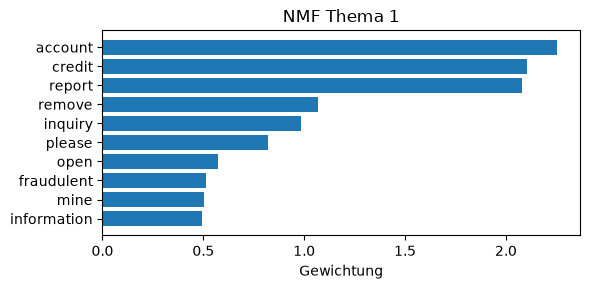

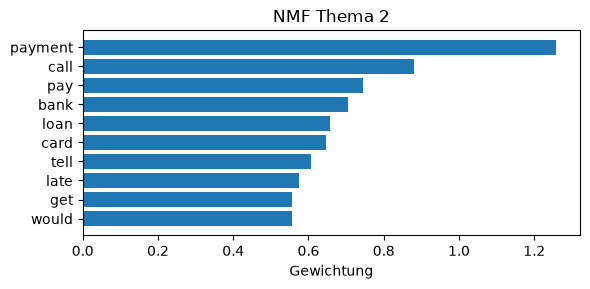

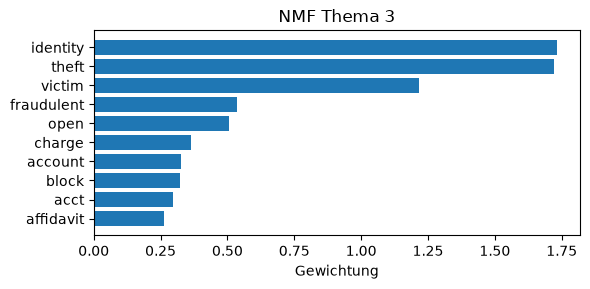

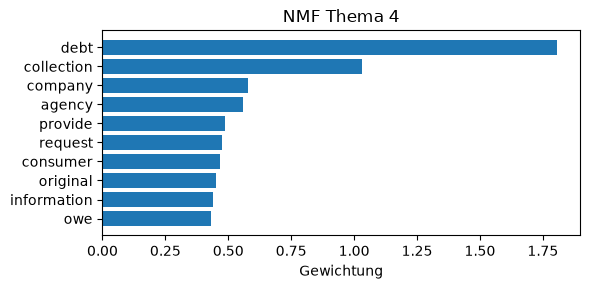

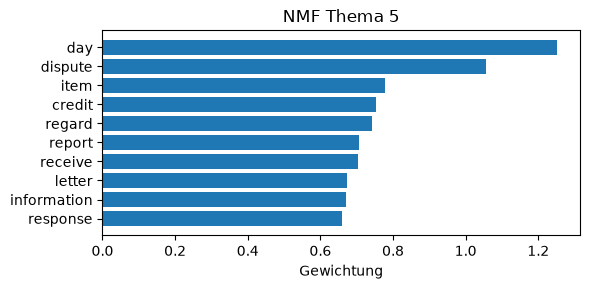

In [9]:
def plot_top_words(model, feature_names, title_prefix, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top = topic.argsort()[-n_top_words:]
        words = [feature_names[i] for i in top]
        weights = topic[top]
        plt.figure(figsize=(6, 3))
        plt.barh(words, weights)
        plt.title(f"{title_prefix} Thema {topic_idx + 1}")
        plt.xlabel("Gewichtung")
        plt.tight_layout()
        plt.show()

plot_top_words(nmf, feature_names, "NMF")

## 7. Visualisierung der LDA-Themen
Die wichtigsten Wörter je Thema mit ihrer Gewichtung (analog zur NMF-Darstellung).

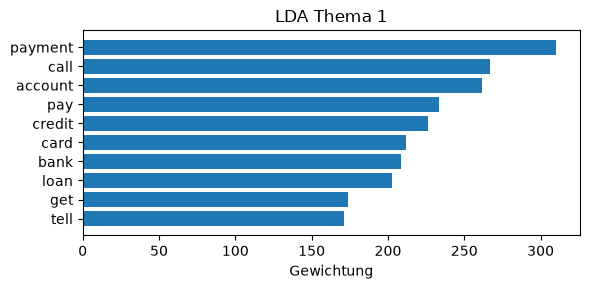

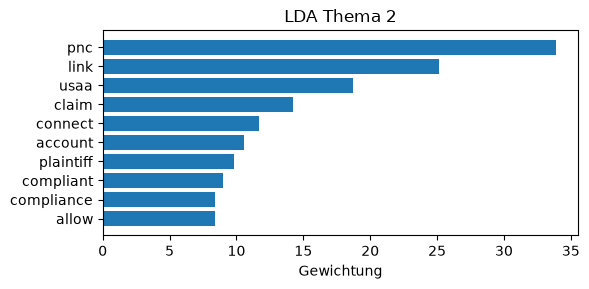

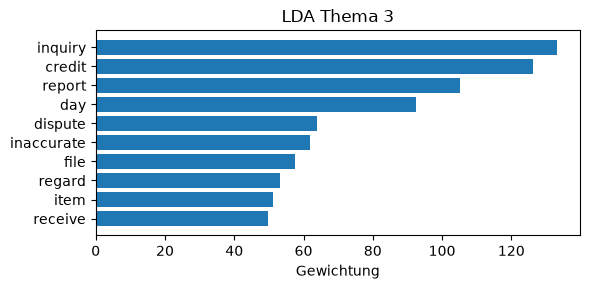

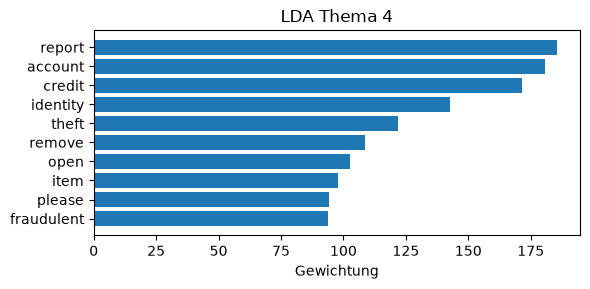

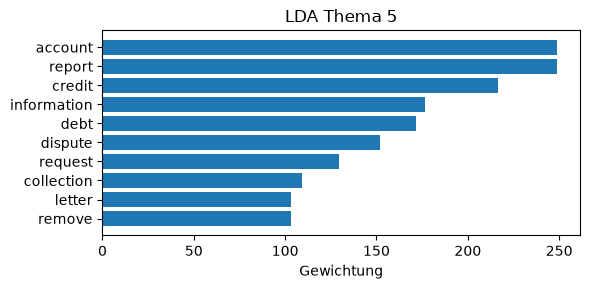

In [10]:
plot_top_words(lda, feature_names, "LDA")